In [1]:
import sys
sys.path.append(r"D:\Code\query-earth\src")

import queryearth

qe = queryearth.QueryEarth()
qe.initialize()

Loading demographic GeoParquet...
Loading local text embedder (sentence-transformers/all-MiniLM-L6-v2)...
cuda


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Initializing OpenCLIP text encoder...
Loading POI GeoParquet...
Loading POI amenity embeddings...


Loading weights:   0%|          | 0/990 [00:00<?, ?it/s]

In [2]:
gdf = qe.find("find me restraurents like mc donalds in Bakersfield California")

a = geocode("Bakersfield, California")
output = poi(a, "restaurants like McDonald's")
[step 1] geocode
  -> 'a': 1 feature(s)
[step 2] poi
POI [class] query "restaurants like McDonald's" matched amenity class(es): ['restaurant', 'closed:restaurant', 'disused:restaurant', 'pub;bar;restaurant', 'bar;restaurant']
  -> 'FINAL_ANSWER': 58 feature(s)
Found the objects in 5.7152745723724365 seconds.


In [13]:
gdf.to_file(rf"results/output2.shp")

In [2]:
gdf = qe.predict("Find EV charging stations near commercial areas in Los Angeles")

a = geocode("Los Angeles")
b = vision-low(a, "commercial areas")
c = buffer(b, 0.2)
output = poi(c, "EV charging stations")
Generated a plan in 1.4469327926635742 sec, the plan is: QueryPlan(steps=[PipelineStep(step_id=1, operation='geocode', parameters={'target': 'Los Angeles', 'resolution': None, 'buffer_distance_km': None}, inputs=[], output_variable='a'), PipelineStep(step_id=2, operation='vision', parameters={'target': 'commercial areas', 'resolution': 'low', 'buffer_distance_km': None}, inputs=['a'], output_variable='b'), PipelineStep(step_id=3, operation='tool', parameters={'target': 'buffer', 'resolution': None, 'buffer_distance_km': 0.2}, inputs=['b'], output_variable='c'), PipelineStep(step_id=4, operation='poi', parameters={'target': 'EV charging stations', 'resolution': None, 'buffer_distance_km': None}, inputs=['c'], output_variable='FINAL_ANSWER')], raw={'dsl': 'a = geocode("Los Angeles")\nb = vision-low(a, "commercial areas")\nc = buffer(b, 0.2)\noutput = poi(c, "EV char

In [3]:
gdf = qe.predict("Find cafes offering outdoor seating in younger census block groups in San Jose")

Raw content: a = geocode("San Jose")
b = demo(a, "younger census block groups")
output = poi(b, "cafes offering outdoor seating")
Generated a plan in 1.2181715965270996 sec, the plan is: QueryPlan(steps=[PipelineStep(step_id=1, operation='geocode', parameters={'target': 'San Jose', 'resolution': None, 'buffer_distance_km': None}, inputs=[], output_variable='a'), PipelineStep(step_id=2, operation='demo', parameters={'target': 'younger census block groups', 'resolution': None, 'buffer_distance_km': None}, inputs=['a'], output_variable='b'), PipelineStep(step_id=3, operation='poi', parameters={'target': 'cafes offering outdoor seating', 'resolution': None, 'buffer_distance_km': None}, inputs=['b'], output_variable='FINAL_ANSWER')], raw={'dsl': 'a = geocode("San Jose")\nb = demo(a, "younger census block groups")\noutput = poi(b, "cafes offering outdoor seating")'})


PLAN:
 QueryPlan(steps=[PipelineStep(step_id=1, operation='geocode', parameters={'target': 'San Jose', 'resolution': None, '

In [5]:
gdf = qe.predict("Which parts of Los Angeles are not adequately covered by fire stations")

Raw content: a = geocode("Los Angeles")
b = demo(a, "fire stations")
output = difference(a, b)
Generated a plan in 1.255397081375122 sec, the plan is: QueryPlan(steps=[PipelineStep(step_id=1, operation='geocode', parameters={'target': 'Los Angeles', 'resolution': None, 'buffer_distance_km': None}, inputs=[], output_variable='a'), PipelineStep(step_id=2, operation='demo', parameters={'target': 'fire stations', 'resolution': None, 'buffer_distance_km': None}, inputs=['a'], output_variable='b'), PipelineStep(step_id=3, operation='tool', parameters={'target': 'difference', 'resolution': None, 'buffer_distance_km': None}, inputs=['a', 'b'], output_variable='FINAL_ANSWER')], raw={'dsl': 'a = geocode("Los Angeles")\nb = demo(a, "fire stations")\noutput = difference(a, b)'})


PLAN:
 QueryPlan(steps=[PipelineStep(step_id=1, operation='geocode', parameters={'target': 'Los Angeles', 'resolution': None, 'buffer_distance_km': None}, inputs=[], output_variable='a'), PipelineStep(step_id=2, operatio

In [5]:
gdf = qe.predict("Find public buildings in Palm Springs that can serve as cooling centers, within walking distance of transit, in high-density neighborhoods with many residents aged 65 and older")

Raw content: a = geocode("Palm Springs")
b = demo(a, "high-density neighborhoods")
c = demo(b, "many residents aged 65 and older")
d = poi(c, "cooling centers")
e = buffer(d, 0.01)
f = poi(e, "transit stations")
g = buffer(f, 0.01)
output = intersection(d, g)
Generated a plan in 1.2358765602111816 sec, the plan is: QueryPlan(steps=[PipelineStep(step_id=1, operation='geocode', parameters={'target': 'Palm Springs', 'resolution': None, 'buffer_distance_km': None}, inputs=[], output_variable='a'), PipelineStep(step_id=2, operation='demo', parameters={'target': 'high-density neighborhoods', 'resolution': None, 'buffer_distance_km': None}, inputs=['a'], output_variable='b'), PipelineStep(step_id=3, operation='demo', parameters={'target': 'many residents aged 65 and older', 'resolution': None, 'buffer_distance_km': None}, inputs=['b'], output_variable='c'), PipelineStep(step_id=4, operation='poi', parameters={'target': 'cooling centers', 'resolution': None, 'buffer_distance_km': None}, inputs

In [6]:
gdf = qe.predict("Find hospitals which are within 20 minutes of wildfire prone areas")

Raw content: a = demo("wildfire prone areas")
b = buffer(a, 0.333)  # ~20 minutes travel time in km (assuming avg speed ~60 km/h)
output = poi(b, "hospitals")
Generated a plan in 1.294177770614624 sec, the plan is: QueryPlan(steps=[PipelineStep(step_id=1, operation='demo', parameters={'target': 'wildfire prone areas', 'resolution': None, 'buffer_distance_km': None}, inputs=[], output_variable='a'), PipelineStep(step_id=2, operation='tool', parameters={'target': 'buffer', 'resolution': None, 'buffer_distance_km': 0.333}, inputs=['a'], output_variable='b'), PipelineStep(step_id=3, operation='poi', parameters={'target': 'hospitals', 'resolution': None, 'buffer_distance_km': None}, inputs=['b'], output_variable='FINAL_ANSWER')], raw={'dsl': 'a = demo("wildfire prone areas")\nb = buffer(a, 0.333)\noutput = poi(b, "hospitals")'})


PLAN:
 QueryPlan(steps=[PipelineStep(step_id=1, operation='demo', parameters={'target': 'wildfire prone areas', 'resolution': None, 'buffer_distance_km': None}, i

In [6]:
gdf = qe.predict("Solar farms in San jose")

Raw content: a = geocode("San Jose")
output = vision-low(a, "solar farms")
Generated a plan in 7.387360334396362 sec, the plan is: QueryPlan(steps=[PipelineStep(step_id=1, operation='geocode', parameters={'target': 'San Jose', 'resolution': None, 'buffer_distance_km': None}, inputs=[], output_variable='a'), PipelineStep(step_id=2, operation='vision', parameters={'target': 'solar farms', 'resolution': 'low', 'buffer_distance_km': None}, inputs=['a'], output_variable='FINAL_ANSWER')], raw={'dsl': 'a = geocode("San Jose")\noutput = vision-low(a, "solar farms")'})


PLAN:
 QueryPlan(steps=[PipelineStep(step_id=1, operation='geocode', parameters={'target': 'San Jose', 'resolution': None, 'buffer_distance_km': None}, inputs=[], output_variable='a'), PipelineStep(step_id=2, operation='vision', parameters={'target': 'solar farms', 'resolution': 'low', 'buffer_distance_km': None}, inputs=['a'], output_variable='FINAL_ANSWER')], raw={'dsl': 'a = geocode("San Jose")\noutput = vision-low(a, "solar

In [7]:
gdf

,geometry,score
0,POINT (-121.74615 37.17052),0.178891
1,POINT (-122.03143 37.45432),0.178438
2,POINT (-121.72228 37.18345),0.164491
3,POINT (-122.0302 37.43192),0.162496
4,POINT (-121.98004 37.41304),0.160189
...,...,...
95,POINT (-121.87134 37.21812),0.109400
96,POINT (-121.77001 37.15759),0.109182
97,POINT (-121.85706 37.41057),0.109131
98,POINT (-121.64832 37.17727),0.108731


In [8]:
from pathlib import Path
import io
from PIL import Image
import pyarrow.parquet as pq

# Paths
parquet_path = r"E:\Data\query-earth\preprocess\images\tiles_2014.parquet"
output_dir = Path(r"E:\Data\query-earth\preprocess\images\preview_output_2014")
output_dir.mkdir(parents=True, exist_ok=True)

# Read only the first row group / first 100 records efficiently
pf = pq.ParquetFile(parquet_path)
table = next(pf.iter_batches(batch_size=100))
df = table.to_pandas()

# Identify image binary column (adjust column name if it differs, e.g., 'image' or 'data')
image_col = "image_bytes"

for idx, row in df.iterrows():
    img_bytes = row[image_col]
    
    # Handle both binary bytes and dictionary payloads
    if isinstance(img_bytes, dict) and 'bytes' in img_bytes:
        img_bytes = img_bytes['bytes']
        
    image = Image.open(io.BytesIO(img_bytes))
    image.save(output_dir / f"tile_{idx:03d}.png")

print(f"Saved {len(df)} preview images to {output_dir}")

Saved 100 preview images to E:\Data\query-earth\preprocess\images\preview_output_2014


In [9]:
import pandas as pd

df = pd.read_parquet(rf"E:\Data\query-earth\preprocess\images\embeddings_2026.parquet")

ArrowInvalid: Could not open Parquet input source '<Buffer>': Parquet magic bytes not found in footer. Either the file is corrupted or this is not a parquet file.

Loading lcybuaa/Git-RSCLIP onto cuda...


Loading weights:   0%|          | 0/792 [00:00<?, ?it/s]

Encoding text queries...
Streaming image embeddings from E:\Data\query-earth\preprocess\vision-emb\low_res_2014.parquet...

--- Image-Text Similarity Distribution ---
Total Evaluated Pairs (Images x Queries): 7,067,400
Mean Similarity: 0.0264
Std Deviation:   0.0209
Generating KDE Plot...


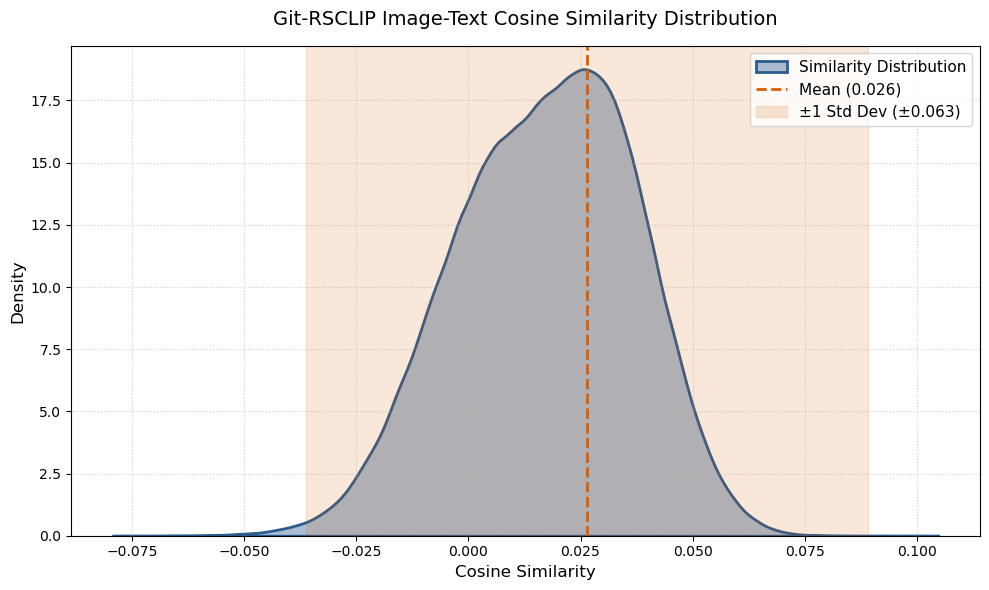

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pyarrow.dataset as ds
import seaborn as sns
import torch
from transformers import AutoModel, AutoProcessor

# Configuration
PARQUET_PATH = r"E:\Data\query-earth\preprocess\vision-emb\low_res_2014.parquet"
EMB_COL = "embedding"
MODEL_NAME = "lcybuaa/Git-RSCLIP"
MAX_KDE_SAMPLES = 500_000  # Max scores to store in RAM for KDE plot

# 1. 100 Aerial Text Queries
QUERIES = [
    # --- Rivers, Water Bodies & Coastal ---
    "a remote sensing image of a river",
    "a satellite photo of a meandering river through valley",
    "aerial view of a wide coastal estuary",
    "satellite image of an ocean coastline with crashing waves",
    "a remote sensing image of a freshwater lake",
    "aerial view of a water reservoir and dam",
    "satellite photo of marshland and wetlands",
    "aerial photograph of a canal network",
    "a remote sensing image of a tropical coral reef",
    "satellite view of a flooded river basin",

    # --- Urban, Housing & Residential ---
    "a remote sensing image of houses and roads",
    "aerial view of a dense residential neighborhood",
    "satellite image of suburban housing developments",
    "aerial photograph of high-rise city skyscrapers",
    "a remote sensing image of urban city streets",
    "satellite view of informal settlement housing",
    "aerial photo of apartment complex buildings",
    "a remote sensing image of a quiet suburban town",
    "satellite image of rooftop solar panels on homes",
    "aerial view of a historic city center with red tiled roofs",

    # --- Transport & Infrastructure ---
    "aerial view of an airport runway",
    "satellite image of a multi-lane highway interchange",
    "a remote sensing image of a railway yard and tracks",
    "aerial photograph of a large suspension bridge",
    "satellite view of a major traffic intersection",
    "a remote sensing image of a parking lot full of cars",
    "aerial view of a container shipping terminal",
    "satellite photo of an airplane taxiway and gates",
    "a remote sensing image of a toll plaza on a highway",
    "aerial view of a pedestrian plaza in a downtown area",

    # --- Forestry, Vegetation & Nature ---
    "satellite image of a dense forest",
    "a remote sensing image of a tropical rainforest canopy",
    "aerial photograph of a pine tree plantation",
    "satellite view of a deforested woodland area",
    "aerial view of a public city park with trees",
    "a remote sensing image of mangrove forest vegetation",
    "satellite photo of temperate broadleaf forest",
    "aerial view of alpine tree lines",
    "a remote sensing image of dry scrubland vegetation",
    "satellite photo of autumn trees showing colored foliage",

    # --- Agriculture & Farmland ---
    "a remote sensing image of agricultural farmland",
    "satellite view of center-pivot irrigation circular fields",
    "aerial photograph of green rectangular crop fields",
    "a remote sensing image of terraced rice paddies",
    "satellite photo of vineyard rows on rolling hills",
    "aerial view of flooded agricultural land",
    "a remote sensing image of plowed brown soil fields",
    "satellite image of greenhouses in agricultural complex",
    "aerial photograph of fruit tree orchards",
    "a remote sensing image of pasture land with livestock",

    # --- Industrial, Energy & Commercial ---
    "a remote sensing image of an industrial zone",
    "aerial view of a oil refinery with storage tanks",
    "satellite image of a utility-scale solar farm",
    "aerial photograph of an onshore wind turbine farm",
    "a remote sensing image of a logistics warehouse complex",
    "satellite view of a chemical manufacturing plant",
    "aerial photo of an open-pit mining quarry",
    "a remote sensing image of a power generation station",
    "satellite view of water treatment facility tanks",
    "aerial view of a factory complex with smoking stacks",

    # --- Harbors, Ports & Maritime ---
    "aerial photograph of a harbor with ships",
    "a remote sensing image of a marina filled with boats",
    "satellite view of cargo ships docked at a pier",
    "aerial photograph of a commercial seaport",
    "a remote sensing image of a ferry terminal",
    "satellite photo of a dry dock shipyard",
    "aerial view of breakwater jetties protecting a cove",
    "a remote sensing image of fishing boats at sea",
    "satellite view of a naval base with vessels",
    "aerial photograph of cruise ships docked at port",

    # --- Arid, Desert & Bare Ground ---
    "satellite image of sand dunes in a desert",
    "a remote sensing image of a dry salt flat basin",
    "aerial view of barren rocky terrain",
    "satellite photo of a canyon and eroded plateau",
    "a remote sensing image of a dry riverbed or wadi",
    "aerial photograph of a desert oasis with vegetation",
    "satellite view of exposed bedrock and gravel",
    "a remote sensing image of a arid mountain pass",
    "satellite photo of red sand dunes",
    "aerial view of badlands topography",

    # --- Snow, Ice & High Altitude ---
    "satellite image of a glacier flowing down a valley",
    "a remote sensing image of snow-capped mountain peaks",
    "aerial photograph of sea ice floes in polar waters",
    "satellite view of a frozen arctic lake",
    "a remote sensing image of a ski resort on a snowy mountain",
    "aerial photo of an ice sheet margin",
    "satellite view of tundra covered in light snow",
    "a remote sensing image of a volcanic crater peak",
    "aerial photograph of a high altitude plateau",
    "satellite view of a glacier terminus in ocean",

    # --- Sports, Recreation & Public Venues ---
    "aerial view of an outdoor sports stadium",
    "a remote sensing image of a golf course with fairways and greens",
    "satellite photo of baseball diamonds and sports fields",
    "aerial view of a race track circuit",
    "a remote sensing image of an amusement park with rides",
    "satellite view of a beach resort along the coast",
    "aerial photograph of swimming pools in a residential area",
    "a remote sensing image of a public square",
    "satellite photo of a university campus layout",
    "aerial view of a cemetery with grid paths"
]
if len(QUERIES) < 100:
    QUERIES = (QUERIES * (100 // len(QUERIES) + 1))[:100]

device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Load Model & Extract Normalized Text Embeddings
print(f"Loading {MODEL_NAME} onto {device}...")
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
processor = AutoProcessor.from_pretrained(MODEL_NAME)
model.eval()

print("Encoding text queries...")
inputs = processor(text=QUERIES, padding=True, return_tensors="pt").to(device)

with torch.no_grad():
    if hasattr(model, "get_text_features"):
        text_features = model.get_text_features(**inputs)
    else:
        text_outputs = model.text_model(**inputs)
        text_features = getattr(text_outputs, "pooler_output", text_outputs[0])

    if hasattr(model, "text_projection"):
        text_features = model.text_projection(text_features)

    text_features = text_features.pooler_output

    # Normalize text embeddings (Cosine Similarity)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

# 3. Stream Parquet & Compute Similarities
print(f"Streaming image embeddings from {PARQUET_PATH}...")
dataset = ds.dataset(PARQUET_PATH, format="parquet")

total_count = 0
sum_sim = 0.0
sum_sq_sim = 0.0
sampled_sims = []

for batch in dataset.to_batches(columns=[EMB_COL]):
    raw_emb = batch[EMB_COL].to_numpy(zero_copy_only=False)
    img_arr = np.vstack(raw_emb).astype(np.float32)

    img_tensors = torch.from_numpy(img_arr).to(device)
    img_tensors = img_tensors / img_tensors.norm(dim=-1, keepdim=True)

    with torch.no_grad():
        sim_matrix = img_tensors @ text_features.T  # (N_images, 100_queries)

    sim_flat = sim_matrix.view(-1).cpu().numpy().astype(np.float64)

    # Accumulate running stats
    total_count += len(sim_flat)
    sum_sim += np.sum(sim_flat)
    sum_sq_sim += np.sum(sim_flat**2)

    # Subsample scores for KDE plotting to conserve memory
    if len(sampled_sims) < MAX_KDE_SAMPLES:
        take_n = min(len(sim_flat), MAX_KDE_SAMPLES - len(sampled_sims))
        sampled_sims.extend(np.random.choice(sim_flat, size=take_n, replace=False))

# 4. Final Distribution Statistics
mean_sim = sum_sim / total_count
variance_sim = (sum_sq_sim / total_count) - (mean_sim**2)
std_sim = np.sqrt(max(0.0, variance_sim))

print("\n--- Image-Text Similarity Distribution ---")
print(f"Total Evaluated Pairs (Images x Queries): {total_count:,}")
print(f"Mean Similarity: {mean_sim:.4f}")
print(f"Std Deviation:   {std_sim:.4f}")

# 5. Plot KDE
print("Generating KDE Plot...")
plt.figure(figsize=(10, 6))

sns.kdeplot(
    sampled_sims,
    fill=True,
    color="#2b5c8f",
    alpha=0.4,
    linewidth=2,
    label="Similarity Distribution",
)

# Overlay Mean and Standard Deviation markers
plt.axvline(
    mean_sim,
    color="#d95f02",
    linestyle="--",
    linewidth=2,
    label=f"Mean ({mean_sim:.3f})",
)
plt.axvspan(
    mean_sim - 3*std_sim,
    mean_sim + 3*std_sim,
    color="#d95f02",
    alpha=0.15,
    label=f"±1 Std Dev (±{3*std_sim:.3f})",
)

plt.title(
    "Git-RSCLIP Image-Text Cosine Similarity Distribution",
    fontsize=14,
    pad=15,
)
plt.xlabel("Cosine Similarity", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend(fontsize=11, loc="upper right")
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()

plt.show()

In [8]:
import io
import math
from typing import List, Tuple, Dict, Any, Optional

import numpy as np
import requests
import torch
from PIL import Image, ImageDraw, ImageFont
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

# ==============================================================================
# 1. MAP PROJECTION & TILE UTILITIES (Zoom Level 17)
# ==============================================================================
TILE_URL_TMPL = (
    "https://wayback.maptiles.arcgis.com/arcgis/rest/services/World_Imagery/"
    "WMTS/1.0.0/default028mm/MapServer/tile/{release_id}/{zoom}/{y}/{x}"
)


def latlon_to_tile(lat: float, lon: float, zoom: int = 17) -> Tuple[int, int]:
    """Converts a lat/lon coordinate into an XYZ tile index."""
    lat_rad = math.radians(lat)
    n = 2.0 ** zoom
    xtile = int((lon + 180.0) / 360.0 * n)
    ytile = int((1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * n)
    return xtile, ytile


def pixel_to_latlon(
    cx: float, cy: float, x_tile: int, y_tile: int, zoom: int = 17, tile_size: int = 256
) -> Tuple[float, float]:
    """Projects pixel (cx, cy) on a specific tile to absolute lat/lon coordinates."""
    n = 2.0 ** zoom
    global_px_x = x_tile * tile_size + cx
    global_px_y = y_tile * tile_size + cy

    lon = (global_px_x / (n * tile_size)) * 360.0 - 180.0
    lat_rad = math.atan(math.sinh(math.pi * (1.0 - 2.0 * (global_px_y / (n * tile_size)))))
    lat = math.degrees(lat_rad)
    return lat, lon


# ==============================================================================
# 2. MAIN GROUNDING & VISUALIZATION PIPELINE
# ==============================================================================
class GroundedVisionPipeline:
    def __init__(
        self,
        model_id: str = "IDEA-Research/grounding-dino-tiny",
        release_id: str = "WB_2023_R01",
    ):
        self.processor = AutoProcessor.from_pretrained(model_id)
        self.model = AutoModelForZeroShotObjectDetection.from_pretrained(
            model_id, device_map="auto"
        )
        self.release_id = release_id
        self.session = requests.Session()

    def fetch_tile(self, lat: float, lon: float, zoom: int = 17) -> Tuple[Optional[Image.Image], Tuple[int, int]]:
        """Downloads satellite tile image given lat/lon."""
        x_tile, y_tile = latlon_to_tile(lat, lon, zoom)
        url = TILE_URL_TMPL.format(release_id=32246, zoom=zoom, y=y_tile, x=x_tile)

        try:
            resp = self.session.get(url, timeout=10)
            if resp.status_code == 200:
                image = Image.open(io.BytesIO(resp.content)).convert("RGB")
                return image, (x_tile, y_tile)
        except requests.RequestException as e:
            print(f"Failed to fetch tile for ({lat}, {lon}): {e}")

        return None, (x_tile, y_tile)

    def process_locations(
        self,
        locations: List[Tuple[float, float]],
        target_prompt: str,
        threshold: float = 0.35,
        text_threshold: float = 0.25,
        zoom: int = 17,
        draw_bboxes: bool = True,
    ) -> List[Dict[str, Any]]:
        """
        Runs object detection on a list of lat/lon coordinates.
        Draws bounding boxes and returns detection data including projected lat/lon of targets.
        """
        # Ensure proper prompt format ending in a dot for GroundingDINO
        formatted_prompt = target_prompt if target_prompt.endswith(".") else f"{target_prompt}."
        text_labels = [formatted_prompt]

        results = []

        for idx, (lat, lon) in enumerate(locations):
            print(f"\nProcessing Location {idx+1}/{len(locations)}: ({lat}, {lon})")

            # 1. Fetch satellite image tile via API
            image, (x_tile, y_tile) = self.fetch_tile(lat, lon, zoom=zoom)
            if image is None:
                continue

            # 2. Run object detection via GroundingDINO
            inputs = self.processor(
                images=image, text=text_labels, return_tensors="pt"
            ).to(self.model.device)

            with torch.no_grad():
                outputs = self.model(**inputs)

            raw_results = self.processor.post_process_grounded_object_detection(
                outputs,
                inputs.input_ids,
                threshold=threshold,
                text_threshold=text_threshold,
                target_sizes=[image.size[::-1]],
            )[0]

            # Prepare visualization image copy
            annotated_image = image.copy()
            draw = ImageDraw.Draw(annotated_image)
            detections = []

            # Try to load a font, fallback to default
            try:
                font = ImageFont.truetype("arial.ttf", 12)
            except IOError:
                font = ImageFont.load_default()

            # 3. Process bounding boxes & project center coordinates back to Lat/Lon
            for box, score, label in zip(
                raw_results["boxes"], raw_results["scores"], raw_results["labels"]
            ):
                box_coords = [round(x, 2) for x in box.tolist()]  # [xmin, ymin, xmax, ymax]
                cx = (box_coords[0] + box_coords[2]) / 2.0
                cy = (box_coords[1] + box_coords[3]) / 2.0

                # Spatial projection: Pixel -> Lat/Lon
                target_lat, target_lon = pixel_to_latlon(cx, cy, x_tile, y_tile, zoom=zoom)

                detection_info = {
                    "label": label,
                    "confidence": round(score.item(), 3),
                    "bbox_px": box_coords,
                    "target_lat": round(target_lat, 6),
                    "target_lon": round(target_lon, 6),
                }
                detections.append(detection_info)

                print(
                    f" Detected '{label}' ({detection_info['confidence']}) "
                    f"at Lat: {detection_info['target_lat']}, Lon: {detection_info['target_lon']} "
                    f"| BBox: {box_coords}"
                )

                # 4. Draw bounding boxes and text labels
                if draw_bboxes:
                    xmin, ymin, xmax, ymax = box_coords
                    draw.rectangle([xmin, ymin, xmax, ymax], outline="red", width=2)
                    text_str = f"{label}: {detection_info['confidence']}"
                    draw.text((xmin + 2, ymin + 2), text_str, fill="yellow", font=font)

            # Store result payload
            location_result = {
                "input_lat": lat,
                "input_lon": lon,
                "detections": detections,
                "image": annotated_image,
            }
            results.append(location_result)

        return results


# ==============================================================================
# 3. EXAMPLE USAGE
# ==============================================================================
if __name__ == "__main__":
    # Define a list of candidate lat/lon coordinates
    locations_list = [
        (25.1972, 55.2744),  # Burj Khalifa area, Dubai
        (25.1304, 55.1172),  # Palm Jumeirah area, Dubai
    ]

    query_target = "pools"

    # Initialize pipeline
    pipeline = GroundedVisionPipeline()

    # Process locations, fetch images, detect objects, and draw bboxes
    output_results = pipeline.process_locations(
        locations=locations_list,
        target_prompt=query_target,
        threshold=0.35,
        zoom=17,
        draw_bboxes=True,
    )

    print(output_results)

    # Save output images with bounding boxes rendered
    for idx, res in enumerate(output_results):
        save_path = f"detection_result_location_{idx+1}.png"
        res["image"].save(save_path)
        print(f"\nSaved annotated tile image to '{save_path}'")

Loading weights:   0%|          | 0/990 [00:00<?, ?it/s]


Processing Location 1/2: (25.1972, 55.2744)
 Detected 'pools' (0.514) at Lat: 25.196242, Lon: 55.27359 | BBox: [0.02, 0.06, 256.02, 256.06]

Processing Location 2/2: (25.1304, 55.1172)
 Detected 'pools' (0.434) at Lat: 25.13161, Lon: 55.117035 | BBox: [0.04, -0.04, 256.04, 255.96]
[{'input_lat': 25.1972, 'input_lon': 55.2744, 'detections': [{'label': 'pools', 'confidence': 0.514, 'bbox_px': [0.02, 0.06, 256.02, 256.06], 'target_lat': 25.196242, 'target_lon': 55.27359}], 'image': <PIL.Image.Image image mode=RGB size=256x256 at 0x21D5E66ECF0>}, {'input_lat': 25.1304, 'input_lon': 55.1172, 'detections': [{'label': 'pools', 'confidence': 0.434, 'bbox_px': [0.04, -0.04, 256.04, 255.96], 'target_lat': 25.13161, 'target_lon': 55.117035}], 'image': <PIL.Image.Image image mode=RGB size=256x256 at 0x21D8AD16F50>}]

Saved annotated tile image to 'detection_result_location_1.png'

Saved annotated tile image to 'detection_result_location_2.png'


In [24]:
import io
import math
from typing import List, Tuple, Dict, Any, Optional

import numpy as np
import requests
import torch
from PIL import Image, ImageDraw
from transformers import (
    AutoProcessor,
    AutoModelForZeroShotObjectDetection,
    AutoModelForMaskGeneration,
)

TILE_URL_TMPL = (
    "https://wayback.maptiles.arcgis.com/arcgis/rest/services/World_Imagery/"
    "WMTS/1.0.0/default028mm/MapServer/tile/{release_id}/{zoom}/{y}/{x}"
)

def latlon_to_tile(lat: float, lon: float, zoom: int = 17) -> Tuple[int, int]:
    lat_rad = math.radians(lat)
    n = 2.0 ** zoom
    xtile = int((lon + 180.0) / 360.0 * n)
    ytile = int((1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * n)
    return xtile, ytile

def pixel_to_latlon(cx: float, cy: float, x_tile: int, y_tile: int, zoom: int = 17) -> Tuple[float, float]:
    n = 2.0 ** zoom
    global_px_x = x_tile * 256 + cx
    global_px_y = y_tile * 256 + cy
    lon = (global_px_x / (n * 256)) * 360.0 - 180.0
    lat_rad = math.atan(math.sinh(math.pi * (1.0 - 2.0 * (global_px_y / (n * 256)))))
    return math.degrees(lat_rad), lon


class GroundedSAMPipeline:
    def __init__(
        self,
        detector_id: str = "IDEA-Research/grounding-dino-tiny",
        segmenter_id: str = "facebook/sam-vit-base",
        release_id: str = "32246",
    ):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.release_id = release_id
        self.session = requests.Session()

        # Load GroundingDINO explicitly with Processor
        self.dino_processor = AutoProcessor.from_pretrained(detector_id)
        self.dino_model = AutoModelForZeroShotObjectDetection.from_pretrained(detector_id).to(self.device)
        self.dino_model.eval()

        # Load SAM
        self.sam_processor = AutoProcessor.from_pretrained(segmenter_id)
        self.sam_model = AutoModelForMaskGeneration.from_pretrained(segmenter_id).to(self.device)
        self.sam_model.eval()

    def fetch_tile(self, lat: float, lon: float, zoom: int = 17) -> Tuple[Optional[Image.Image], Tuple[int, int]]:
        x_tile, y_tile = latlon_to_tile(lat, lon, zoom)
        url = TILE_URL_TMPL.format(release_id=self.release_id, zoom=zoom, y=y_tile, x=x_tile)
        try:
            resp = self.session.get(url, timeout=10)
            if resp.status_code == 200:
                return Image.open(io.BytesIO(resp.content)).convert("RGB"), (x_tile, y_tile)
        except requests.RequestException:
            pass
        return None, (x_tile, y_tile)

    def process_locations(
        self,
        locations: List[Tuple[float, float]],
        labels: List[str],
        box_threshold: float = 0.40,
        text_threshold: float = 0.30,
        zoom: int = 17,
    ) -> List[Dict[str, Any]]:
        # Format text queries for GroundingDINO
        formatted_labels = [l if l.endswith(".") else f"{l}." for l in labels]
        results = []

        for lat, lon in locations:
            image, (x_tile, y_tile) = self.fetch_tile(lat, lon, zoom=zoom)
            if image is None:
                continue

            # 1. GroundingDINO Detection
            inputs = self.dino_processor(images=image, text=formatted_labels, return_tensors="pt").to(self.device)
            with torch.no_grad():
                outputs = self.dino_model(**inputs)

            dino_results = self.dino_processor.post_process_grounded_object_detection(
                outputs,
                inputs.input_ids,
                threshold=box_threshold,
                text_threshold=text_threshold,
                target_sizes=[image.size[::-1]],
            )[0]

            # 2. Filter out edge-case / full-tile candidate boxes
            valid_boxes = []
            valid_scores = []
            valid_labels = []

            w_img, h_img = image.size
            total_area = w_img * h_img

            for box, score, label in zip(dino_results["boxes"], dino_results["scores"], dino_results["labels"]):
                b = [round(x, 2) for x in box.tolist()]  # [xmin, ymin, xmax, ymax]
                box_area = (b[2] - b[0]) * (b[3] - b[1])

                # Reject boxes covering > 75% of the entire tile image
                if box_area < 0.75 * total_area and (b[2] - b[0]) > 5 and (b[3] - b[1]) > 5:
                    valid_boxes.append(b)
                    valid_scores.append(round(score.item(), 3))
                    valid_labels.append(label)

            if not valid_boxes:
                print(f"No valid targets found for location ({lat}, {lon}).")
                continue

            # 3. Prompt SAM with valid filtered bounding boxes
            # Format expected by SAM Processor: [[[xmin, ymin, xmax, ymax], ...]]
            sam_inputs = self.sam_processor(
                images=image,
                input_boxes=[valid_boxes],
                return_tensors="pt"
            ).to(self.device)

            with torch.no_grad():
                sam_outputs = self.sam_model(**sam_inputs)

            masks = self.sam_processor.post_process_masks(
                masks=sam_outputs.pred_masks,
                original_sizes=sam_inputs.original_sizes,
                reshaped_input_sizes=sam_inputs.reshaped_input_sizes,
            )[0]

            # 4. Draw overlays
            annotated_image = image.copy()
            draw = ImageDraw.Draw(annotated_image)
            location_detections = []

            for box, score, label, mask_set in zip(valid_boxes, valid_scores, valid_labels, masks):
                # Pick the highest confidence mask variant from SAM output (Index 0)
                mask_np = mask_set[0].cpu().numpy().astype(bool)

                # Get exact centroid from SAM mask
                y_idx, x_idx = np.where(mask_np)
                if len(x_idx) > 0:
                    cx, cy = float(np.mean(x_idx)), float(np.mean(y_idx))
                else:
                    cx, cy = (box[0] + box[2]) / 2.0, (box[1] + box[3]) / 2.0

                target_lat, target_lon = pixel_to_latlon(cx, cy, x_tile, y_tile, zoom=zoom)

                # Render red mask overlay
                mask_overlay = Image.new("RGBA", image.size, (0, 0, 0, 0))
                ImageDraw.Draw(mask_overlay).bitmap((0, 0), Image.fromarray(mask_np), fill=(255, 0, 0, 120))
                annotated_image.paste(mask_overlay, (0, 0), mask_overlay)

                # Render yellow bounding box border
                draw.rectangle(box, outline="yellow", width=2)

                location_detections.append({
                    "label": label,
                    "confidence": score,
                    "target_lat": round(target_lat, 6),
                    "target_lon": round(target_lon, 6),
                    "mask": mask_np,
                })

            results.append({
                "input_lat": lat,
                "input_lon": lon,
                "detections": location_detections,
                "image": annotated_image,
            })

        return results

In [25]:
if __name__ == "__main__":
    locations_list = [
        (34.203528776703884, -118.46943679373796),
    ]

    labels = ["swimming pool"]

    # Initialize Grounded SAM
    pipeline = GroundedSAMPipeline()

    # Run detection + SAM segmentation
    output_results = pipeline.process_locations(
        locations=locations_list,
        labels=labels,
        box_threshold=0.2,
        zoom=17,
    )

    # Save visualization results with mask overlays
    for idx, res in enumerate(output_results):
        save_path = f"grounded_sam_result_{idx+1}.png"
        res["image"].save(save_path)
        print(f"Saved segmented image to {save_path}")

Loading weights:   0%|          | 0/990 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

Saved segmented image to grounded_sam_result_1.png


In [16]:
import io
import math
import tqdm
from typing import List, Tuple, Dict, Any, Optional

import numpy as np
import requests
import torch
from PIL import Image, ImageDraw
from transformers import (
    AutoProcessor,
    AutoModelForZeroShotObjectDetection,
    AutoModelForMaskGeneration,
)

TILE_URL_TMPL = (
    "https://wayback.maptiles.arcgis.com/arcgis/rest/services/World_Imagery/"
    "WMTS/1.0.0/default028mm/MapServer/tile/{release_id}/{zoom}/{y}/{x}"
)

def latlon_to_tile_float(lat: float, lon: float, zoom: int = 17) -> Tuple[float, float]:
    """Returns continuous float tile coordinates."""
    lat_rad = math.radians(lat)
    n = 2.0 ** zoom
    xtile = (lon + 180.0) / 360.0 * n
    ytile = (1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * n
    return xtile, ytile

def pixel_to_latlon_centered(
    px: float, py: float, center_lat: float, center_lon: float, image_size: int = 512, zoom: int = 17
) -> Tuple[float, float]:
    """Projects pixel offset on a composite image centered at (center_lat, center_lon) back to Lat/Lon."""
    n = 2.0 ** zoom
    center_xtile, center_ytile = latlon_to_tile_float(center_lat, center_lon, zoom)
    
    # Global pixel coordinate of tile center
    center_global_x = center_xtile * 256.0
    center_global_y = center_ytile * 256.0

    # Calculate offset relative to composite image center
    offset_x = px - (image_size / 2.0)
    offset_y = py - (image_size / 2.0)

    target_global_x = center_global_x + offset_x
    target_global_y = center_global_y + offset_y

    lon = (target_global_x / (n * 256.0)) * 360.0 - 180.0
    lat_rad = math.atan(math.sinh(math.pi * (1.0 - 2.0 * (target_global_y / (n * 256.0)))))
    return math.degrees(lat_rad), lon


class GroundedSAMPipeline:
    def __init__(
        self,
        detector_id: str = "IDEA-Research/grounding-dino-base",
        segmenter_id: str = "facebook/sam-vit-huge",
        release_id: str = "32246",
    ):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.release_id = release_id
        self.session = requests.Session()

        print(f"Loading GroundingDINO ('{detector_id}') on {self.device}...")
        self.dino_processor = AutoProcessor.from_pretrained(detector_id)
        self.dino_model = AutoModelForZeroShotObjectDetection.from_pretrained(detector_id).to(self.device)
        self.dino_model.eval()

        print(f"Loading SAM ('{segmenter_id}') on {self.device}...")
        self.sam_processor = AutoProcessor.from_pretrained(segmenter_id)
        self.sam_model = AutoModelForMaskGeneration.from_pretrained(segmenter_id).to(self.device)
        self.sam_model.eval()

    def fetch_composite_image(
        self, lat: float, lon: float, zoom: int = 17, image_size: int = 512
    ) -> Optional[Image.Image]:
        """
        Stitches satellite tiles to create a higher resolution crop (e.g. 512x512)
        centered precisely at (lat, lon).
        """
        x_float, y_float = latlon_to_tile_float(lat, lon, zoom)
        
        # Center tile index and pixel offset within center tile
        center_x_int, center_y_int = int(x_float), int(y_float)
        px_offset_x = int((x_float - center_x_int) * 256)
        px_offset_y = int((y_float - center_y_int) * 256)

        # Create 3x3 tile canvas (768x768)
        canvas = Image.new("RGB", (256 * 3, 256 * 3))

        for dx in range(-1, 2):
            for dy in range(-1, 2):
                tx = center_x_int + dx
                ty = center_y_int + dy
                url = TILE_URL_TMPL.format(release_id=self.release_id, zoom=zoom, y=ty, x=tx)
                try:
                    resp = self.session.get(url, timeout=10)
                    if resp.status_code == 200:
                        tile_img = Image.open(io.BytesIO(resp.content)).convert("RGB")
                        canvas.paste(tile_img, ((dx + 1) * 256, (dy + 1) * 256))
                except requests.RequestException:
                    pass

        # Crop high-resolution patch centered at target point
        center_px_canvas_x = 256 + px_offset_x
        center_px_canvas_y = 256 + px_offset_y

        half_sz = image_size // 2
        crop_box = (
            center_px_canvas_x - half_sz,
            center_px_canvas_y - half_sz,
            center_px_canvas_x + half_sz,
            center_px_canvas_y + half_sz,
        )

        return canvas.crop(crop_box)

    def process_locations(
        self,
        locations: List[Tuple[float, float]],
        labels: List[str],
        top_k: int = 5,
        min_threshold: float = 0.20,
        zoom: int = 17,
        image_size: int = 512,  # Increase resolution sent to model
    ) -> List[Dict[str, Any]]:
        formatted_labels = [l if l.endswith(".") else f"{l}." for l in labels]
        results = []

        for lat, lon in tqdm.tqdm(locations):
            image = self.fetch_composite_image(lat, lon, zoom=zoom, image_size=image_size)
            if image is None:
                continue

            # 1. GroundingDINO Detection
            inputs = self.dino_processor(images=image, text=formatted_labels, return_tensors="pt").to(self.device)
            with torch.no_grad():
                outputs = self.dino_model(**inputs)

            dino_results = self.dino_processor.post_process_grounded_object_detection(
                outputs,
                inputs.input_ids,
                threshold=min_threshold,
                text_threshold=min_threshold,
                target_sizes=[image.size[::-1]],
            )[0]

            # 2. Extract and Filter Candidate Boxes
            raw_boxes = dino_results["boxes"]
            raw_scores = dino_results["scores"]
            raw_labels = dino_results["labels"]

            candidates = []
            total_area = image.width * image.height

            for box, score, label in zip(raw_boxes, raw_scores, raw_labels):
                b = [round(x, 2) for x in box.tolist()]  # [xmin, ymin, xmax, ymax]
                box_area = (b[2] - b[0]) * (b[3] - b[1])

                # Reject full image false positives
                if box_area < 0.70 * total_area and (b[2] - b[0]) > 6 and (b[3] - b[1]) > 6:
                    candidates.append({
                        "box": b,
                        "score": round(score.item(), 4),
                        "label": label
                    })

            # Sort and pick Top-K
            candidates = sorted(candidates, key=lambda x: x["score"], reverse=True)[:top_k]

            if not candidates:
                print(f"No valid detections found for ({lat}, {lon}).")
                continue

            top_boxes = [c["box"] for c in candidates]
            top_scores = [c["score"] for c in candidates]
            top_labels = [c["label"] for c in candidates]

            # 3. Feed higher-resolution boxes to SAM
            sam_inputs = self.sam_processor(
                images=image,
                input_boxes=[top_boxes],
                return_tensors="pt"
            ).to(self.device)

            with torch.no_grad():
                sam_outputs = self.sam_model(**sam_inputs)

            masks = self.sam_processor.post_process_masks(
                masks=sam_outputs.pred_masks,
                original_sizes=sam_inputs.original_sizes,
                reshaped_input_sizes=sam_inputs.reshaped_input_sizes,
            )[0]

            # 4. Process and Draw Output
            annotated_image = image.copy()
            draw = ImageDraw.Draw(annotated_image)
            location_detections = []

            for box, score, label, mask_set in zip(top_boxes, top_scores, top_labels, masks):
                mask_np = mask_set[0].cpu().numpy().astype(bool)

                y_idx, x_idx = np.where(mask_np)
                if len(x_idx) > 0:
                    cx, cy = float(np.mean(x_idx)), float(np.mean(y_idx))
                else:
                    cx, cy = (box[0] + box[2]) / 2.0, (box[1] + box[3]) / 2.0

                target_lat, target_lon = pixel_to_latlon_centered(
                    cx, cy, lat, lon, image_size=image_size, zoom=zoom
                )

                mask_overlay = Image.new("RGBA", image.size, (0, 0, 0, 0))
                ImageDraw.Draw(mask_overlay).bitmap((0, 0), Image.fromarray(mask_np), fill=(255, 0, 0, 120))
                annotated_image.paste(mask_overlay, (0, 0), mask_overlay)

                draw.rectangle(box, outline="yellow", width=2)

                location_detections.append({
                    "label": label,
                    "confidence": score,
                    "target_lat": round(target_lat, 6),
                    "target_lon": round(target_lon, 6),
                    "mask": mask_np,
                })
                print(f"Top-K Match: '{label}' ({score}) at Lat: {round(target_lat, 6)}, Lon: {round(target_lon, 6)}")

            results.append({
                "input_lat": lat,
                "input_lon": lon,
                "detections": location_detections,
                "image": annotated_image,
            })

        return results


if __name__ == "__main__":
    locations_list = [
        (34.203528776703884, -118.46943679373796),
        (34.20708237822411, -118.46030669788239),
        (34.20516610191345, -118.46962746151708)
    ]

    labels = ["red roof"]

    pipeline = GroundedSAMPipeline()

    output_results = pipeline.process_locations(
        locations=locations_list,
        labels=labels,
        top_k=5,
        min_threshold=0.20,
        zoom=18,
        image_size=1024,  # Fetching 512x512 composite satellite imagery
    )

    for idx, res in enumerate(output_results):
        save_path = f"grounded_sam_hd_result_{idx+1}.png"
        res["image"].save(save_path)
        print(f"Saved segmented image to {save_path}")

Loading GroundingDINO ('IDEA-Research/grounding-dino-base') on cuda...


Loading weights:   0%|          | 0/1206 [00:00<?, ?it/s]

Loading SAM ('facebook/sam-vit-huge') on cuda...


Loading weights:   0%|          | 0/594 [00:00<?, ?it/s]

 33%|███▎      | 1/3 [00:13<00:27, 13.75s/it]

...

 67%|██████▋   | 2/3 [00:21<00:09,  9.97s/it]

Top-K Match: 'red roof' (0.5959) at Lat: 34.206522, Lon: -118.459455
Top-K Match: 'red roof' (0.2914) at Lat: 34.205965, Lon: -118.46225
Top-K Match: 'red roof' (0.2285) at Lat: 34.205557, Lon: -118.462043


100%|██████████| 3/3 [00:27<00:00,  9.25s/it]

Top-K Match: 'red roof' (0.4009) at Lat: 34.205585, Lon: -118.469143
Top-K Match: 'red roof' (0.3331) at Lat: 34.206416, Lon: -118.467664
Top-K Match: 'red roof' (0.2638) at Lat: 34.205071, Lon: -118.467959
Top-K Match: 'red roof' (0.2518) at Lat: 34.206951, Lon: -118.469246
Top-K Match: 'red roof' (0.2387) at Lat: 34.206319, Lon: -118.468542


Saved segmented image to grounded_sam_hd_result_1.png
Saved segmented image to grounded_sam_hd_result_2.png
Saved segmented image to grounded_sam_hd_result_3.png


In [17]:
import io
import math
import tqdm
from typing import List, Tuple, Dict, Any, Optional

import requests
import torch
from PIL import Image, ImageDraw, ImageFont
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

TILE_URL_TMPL = (
    "https://wayback.maptiles.arcgis.com/arcgis/rest/services/World_Imagery/"
    "WMTS/1.0.0/default028mm/MapServer/tile/{release_id}/{zoom}/{y}/{x}"
)


def latlon_to_tile_float(lat: float, lon: float, zoom: int = 17) -> Tuple[float, float]:
    """Returns continuous float tile coordinates."""
    lat_rad = math.radians(lat)
    n = 2.0**zoom
    xtile = (lon + 180.0) / 360.0 * n
    ytile = (1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * n
    return xtile, ytile


def pixel_to_latlon_centered(
    px: float,
    py: float,
    center_lat: float,
    center_lon: float,
    image_size: int = 512,
    zoom: int = 17,
) -> Tuple[float, float]:
    """Projects pixel offset on a composite image back to Lat/Lon."""
    n = 2.0**zoom
    center_xtile, center_ytile = latlon_to_tile_float(center_lat, center_lon, zoom)

    center_global_x = center_xtile * 256.0
    center_global_y = center_ytile * 256.0

    offset_x = px - (image_size / 2.0)
    offset_y = py - (image_size / 2.0)

    target_global_x = center_global_x + offset_x
    target_global_y = center_global_y + offset_y

    lon = (target_global_x / (n * 256.0)) * 360.0 - 180.0
    lat_rad = math.atan(
        math.sinh(math.pi * (1.0 - 2.0 * (target_global_y / (n * 256.0))))
    )
    return math.degrees(lat_rad), lon


class GroundingDINOPipeline:
    def __init__(
        self,
        detector_id: str = "IDEA-Research/grounding-dino-base",
        release_id: str = "32246",
    ):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.release_id = release_id
        self.session = requests.Session()

        print(f"Loading GroundingDINO Base ('{detector_id}') on {self.device}...")
        self.dino_processor = AutoProcessor.from_pretrained(detector_id)
        self.dino_model = AutoModelForZeroShotObjectDetection.from_pretrained(
            detector_id
        ).to(self.device)
        self.dino_model.eval()

    def fetch_composite_image(
        self, lat: float, lon: float, zoom: int = 17, image_size: int = 512
    ) -> Optional[Image.Image]:
        """Stitches satellite tiles to create a higher resolution image."""
        x_float, y_float = latlon_to_tile_float(lat, lon, zoom)

        center_x_int, center_y_int = int(x_float), int(y_float)
        px_offset_x = int((x_float - center_x_int) * 256)
        px_offset_y = int((y_float - center_y_int) * 256)

        canvas = Image.new("RGB", (256 * 3, 256 * 3))

        for dx in range(-1, 2):
            for dy in range(-1, 2):
                tx = center_x_int + dx
                ty = center_y_int + dy
                url = TILE_URL_TMPL.format(
                    release_id=self.release_id, zoom=zoom, y=ty, x=tx
                )
                try:
                    resp = self.session.get(url, timeout=10)
                    if resp.status_code == 200:
                        tile_img = Image.open(io.BytesIO(resp.content)).convert("RGB")
                        canvas.paste(tile_img, ((dx + 1) * 256, (dy + 1) * 256))
                except requests.RequestException:
                    pass

        center_px_canvas_x = 256 + px_offset_x
        center_px_canvas_y = 256 + px_offset_y

        half_sz = image_size // 2
        crop_box = (
            center_px_canvas_x - half_sz,
            center_px_canvas_y - half_sz,
            center_px_canvas_x + half_sz,
            center_px_canvas_y + half_sz,
        )

        return canvas.crop(crop_box)

    def process_locations(
        self,
        locations: List[Tuple[float, float]],
        labels: List[str],
        top_k: int = 5,
        min_threshold: float = 0.20,
        zoom: int = 18,
        image_size: int = 1024,
    ) -> List[Dict[str, Any]]:
        formatted_labels = [l if l.endswith(".") else f"{l}." for l in labels]
        results = []

        for lat, lon in tqdm.tqdm(locations, desc="Processing Locations"):
            image = self.fetch_composite_image(
                lat, lon, zoom=zoom, image_size=image_size
            )
            if image is None:
                continue

            # 1. GroundingDINO Inference
            inputs = self.dino_processor(
                images=image, text=formatted_labels, return_tensors="pt"
            ).to(self.device)

            with torch.no_grad():
                outputs = self.dino_model(**inputs)

            dino_results = (
                self.dino_processor.post_process_grounded_object_detection(
                    outputs,
                    inputs.input_ids,
                    threshold=min_threshold,
                    text_threshold=min_threshold,
                    target_sizes=[image.size[::-1]],
                )[0]
            )

            # 2. Candidate Filtering & Box Area Check
            raw_boxes = dino_results["boxes"]
            raw_scores = dino_results["scores"]
            raw_labels = dino_results["labels"]

            candidates = []
            total_area = image.width * image.height

            for box, score, label in zip(raw_boxes, raw_scores, raw_labels):
                b = [round(x, 2) for x in box.tolist()]  # [xmin, ymin, xmax, ymax]
                box_area = (b[2] - b[0]) * (b[3] - b[1])

                # Exclude full-image false positives and micro-noise
                if (
                    box_area < 0.70 * total_area
                    and (b[2] - b[0]) > 6
                    and (b[3] - b[1]) > 6
                ):
                    candidates.append(
                        {
                            "box": b,
                            "score": round(score.item(), 4),
                            "label": label,
                        }
                    )

            # 3. Sort by confidence and grab Top-K
            candidates = sorted(
                candidates, key=lambda x: x["score"], reverse=True
            )[:top_k]

            if not candidates:
                print(f"No valid detections found for ({lat}, {lon}).")
                continue

            # 4. Render Bounding Boxes & Text Annotations
            annotated_image = image.copy()
            draw = ImageDraw.Draw(annotated_image)

            try:
                font = ImageFont.truetype("arial.ttf", 14)
            except IOError:
                font = ImageFont.load_default()

            location_detections = []

            for cand in candidates:
                box = cand["box"]
                score = cand["score"]
                label = cand["label"]

                # Calculate bounding box centroid in pixels
                cx = (box[0] + box[2]) / 2.0
                cy = (box[1] + box[3]) / 2.0

                # Project centroid to real-world coordinates
                target_lat, target_lon = pixel_to_latlon_centered(
                    cx, cy, lat, lon, image_size=image_size, zoom=zoom
                )

                # Draw Bounding Box & Label Tag
                draw.rectangle(box, outline="yellow", width=3)
                label_text = f"{label}: {score}"
                draw.text((box[0] + 3, box[1] + 3), label_text, fill="red", font=font)

                location_detections.append(
                    {
                        "label": label,
                        "confidence": score,
                        "box_px": box,
                        "target_lat": round(target_lat, 6),
                        "target_lon": round(target_lon, 6),
                    }
                )

                print(
                    f" Match: '{label}' ({score}) at Lat: {round(target_lat, 6)}, Lon: {round(target_lon, 6)}"
                )

            results.append(
                {
                    "input_lat": lat,
                    "input_lon": lon,
                    "detections": location_detections,
                    "image": annotated_image,
                }
            )

        return results


if __name__ == "__main__":
    locations_list = [
        (34.203528776703884, -118.46943679373796),
        (34.20708237822411, -118.46030669788239),
        (34.20516610191345, -118.46962746151708),
    ]

    labels = ["red roof"]

    # Initialize pure GroundingDINO base pipeline
    pipeline = GroundingDINOPipeline(detector_id="IDEA-Research/grounding-dino-base")

    output_results = pipeline.process_locations(
        locations=locations_list,
        labels=labels,
        top_k=5,
        min_threshold=0.20,
        zoom=18,
        image_size=1024,
    )

    for idx, res in enumerate(output_results):
        save_path = f"grounding_dino_hd_result_{idx+1}.png"
        res["image"].save(save_path)
        print(f"Saved annotated image to {save_path}")

Loading GroundingDINO Base ('IDEA-Research/grounding-dino-base') on cuda...


Loading weights:   0%|          | 0/1206 [00:00<?, ?it/s]

Processing Locations:  33%|███▎      | 1/3 [00:07<00:14,  7.22s/it]

 Match: 'red roof' (0.4183) at Lat: 34.203264, Lon: -118.468987
 Match: 'red roof' (0.3954) at Lat: 34.202764, Lon: -118.470009
 Match: 'red roof' (0.2362) at Lat: 34.2019, Lon: -118.470748
 Match: 'red' (0.2042) at Lat: 34.203193, Lon: -118.468994
 Match: 'red' (0.2032) at Lat: 34.20328, Lon: -118.470169


Processing Locations:  67%|██████▋   | 2/3 [00:13<00:06,  6.50s/it]

 Match: 'red roof' (0.5959) at Lat: 34.206535, Lon: -118.459418
 Match: 'red roof' (0.2914) at Lat: 34.205966, Lon: -118.462249
 Match: 'red roof' (0.2285) at Lat: 34.205554, Lon: -118.462034


Processing Locations: 100%|██████████| 3/3 [00:19<00:00,  6.41s/it]

 Match: 'red roof' (0.4009) at Lat: 34.20555, Lon: -118.469014
 Match: 'red roof' (0.3331) at Lat: 34.206405, Lon: -118.467661
 Match: 'red roof' (0.2638) at Lat: 34.205069, Lon: -118.467959
 Match: 'red roof' (0.2518) at Lat: 34.206954, Lon: -118.469245
 Match: 'red roof' (0.2387) at Lat: 34.206329, Lon: -118.468542
Saved annotated image to grounding_dino_hd_result_1.png


Saved annotated image to grounding_dino_hd_result_2.png
Saved annotated image to grounding_dino_hd_result_3.png


In [30]:
import io
import math
import tqdm
from typing import List, Tuple, Dict, Any, Optional

import requests
import torch
from PIL import Image, ImageDraw, ImageFont
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

TILE_URL_TMPL = (
    "https://wayback.maptiles.arcgis.com/arcgis/rest/services/World_Imagery/"
    "WMTS/1.0.0/default028mm/MapServer/tile/{release_id}/{zoom}/{y}/{x}"
)

def latlon_to_tile_float(lat: float, lon: float, zoom: int = 17) -> Tuple[float, float]:
    lat_rad = math.radians(lat)
    n = 2.0**zoom
    xtile = (lon + 180.0) / 360.0 * n
    ytile = (1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * n
    return xtile, ytile

def pixel_to_latlon_centered(
    px: float, py: float, center_lat: float, center_lon: float, image_size: int = 512, zoom: int = 17
) -> Tuple[float, float]:
    n = 2.0**zoom
    center_xtile, center_ytile = latlon_to_tile_float(center_lat, center_lon, zoom)
    center_global_x = center_xtile * 256.0
    center_global_y = center_ytile * 256.0

    offset_x = px - (image_size / 2.0)
    offset_y = py - (image_size / 2.0)

    target_global_x = center_global_x + offset_x
    target_global_y = center_global_y + offset_y

    lon = (target_global_x / (n * 256.0)) * 360.0 - 180.0
    lat_rad = math.atan(math.sinh(math.pi * (1.0 - 2.0 * (target_global_y / (n * 256.0)))))
    return math.degrees(lat_rad), lon


class GroundingDINOPipeline:
    def __init__(
        self,
        detector_id: str = "IDEA-Research/grounding-dino-base",
        release_id: str = "32246",
    ):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.release_id = release_id
        self.session = requests.Session()

        print(f"Loading GroundingDINO Base ('{detector_id}') on {self.device}...")
        self.dino_processor = AutoProcessor.from_pretrained(detector_id)
        self.dino_model = AutoModelForZeroShotObjectDetection.from_pretrained(detector_id).to(self.device)
        self.dino_model.eval()

    def fetch_composite_image(
        self, lat: float, lon: float, zoom: int = 17, image_size: int = 512
    ) -> Optional[Image.Image]:
        x_float, y_float = latlon_to_tile_float(lat, lon, zoom)
        center_x_int, center_y_int = int(x_float), int(y_float)
        px_offset_x = int((x_float - center_x_int) * 256)
        px_offset_y = int((y_float - center_y_int) * 256)

        canvas = Image.new("RGB", (256 * 3, 256 * 3))

        for dx in range(-1, 2):
            for dy in range(-1, 2):
                tx = center_x_int + dx
                ty = center_y_int + dy
                url = TILE_URL_TMPL.format(release_id=self.release_id, zoom=zoom, y=ty, x=tx)
                try:
                    resp = self.session.get(url, timeout=10)
                    if resp.status_code == 200:
                        tile_img = Image.open(io.BytesIO(resp.content)).convert("RGB")
                        canvas.paste(tile_img, ((dx + 1) * 256, (dy + 1) * 256))
                except requests.RequestException:
                    pass

        center_px_canvas_x = 256 + px_offset_x
        center_px_canvas_y = 256 + px_offset_y
        half_sz = image_size // 2

        return canvas.crop((
            center_px_canvas_x - half_sz,
            center_px_canvas_y - half_sz,
            center_px_canvas_x + half_sz,
            center_px_canvas_y + half_sz,
        ))

    def process_locations(
        self,
        locations: List[Tuple[float, float]],
        labels: List[str],
        top_k: int = 5,
        box_threshold: float = 0.25,
        text_threshold: float = 0.25,
        zoom: int = 18,
        image_size: int = 1024,
    ) -> List[Dict[str, Any]]:
        
        # 1. Format queries as full descriptive phrases ending with a period
        formatted_prompt = " . ".join([f"a {l.strip('.')}" for l in labels]) + " ."

        results = []

        for lat, lon in tqdm.tqdm(locations, desc="Processing Locations"):
            image = self.fetch_composite_image(lat, lon, zoom=zoom, image_size=image_size)
            if image is None:
                continue

            # 2. Tokenize prompt as continuous text string
            inputs = self.dino_processor(
                images=image, text=formatted_prompt, return_tensors="pt"
            ).to(self.device)

            with torch.no_grad():
                outputs = self.dino_model(**inputs)

            # 3. Post-process enforcing higher threshold on phrase alignment
            dino_results = self.dino_processor.post_process_grounded_object_detection(
                outputs,
                inputs.input_ids,
                text_threshold=text_threshold,
                target_sizes=[image.size[::-1]],
            )[0]

            raw_boxes = dino_results["boxes"]
            raw_scores = dino_results["scores"]
            raw_labels = dino_results["labels"]

            candidates = []
            total_area = image.width * image.height

            for box, score, label in zip(raw_boxes, raw_scores, raw_labels):
                b = [round(x, 2) for x in box.tolist()]
                box_area = (b[2] - b[0]) * (b[3] - b[1])

                if box_area < 0.70 * total_area and (b[2] - b[0]) > 6 and (b[3] - b[1]) > 6:
                    candidates.append({
                        "box": b,
                        "score": round(score.item(), 4),
                        "label": label,
                    })

            candidates = sorted(candidates, key=lambda x: x["score"], reverse=True)[:top_k]

            if not candidates:
                print(f"No valid detections found for ({lat}, {lon}).")
                continue

            annotated_image = image.copy()
            draw = ImageDraw.Draw(annotated_image)

            try:
                font = ImageFont.truetype("arial.ttf", 14)
            except IOError:
                font = ImageFont.load_default()

            location_detections = []

            for cand in candidates:
                box, score, label = cand["box"], cand["score"], cand["label"]
                cx = (box[0] + box[2]) / 2.0
                cy = (box[1] + box[3]) / 2.0

                target_lat, target_lon = pixel_to_latlon_centered(
                    cx, cy, lat, lon, image_size=image_size, zoom=zoom
                )

                draw.rectangle(box, outline="yellow", width=3)
                draw.text((box[0] + 3, box[1] + 3), f"{label}: {score}", fill="red", font=font)

                location_detections.append({
                    "label": label,
                    "confidence": score,
                    "box_px": box,
                    "target_lat": round(target_lat, 6),
                    "target_lon": round(target_lon, 6),
                })

                print(f" Match: '{label}' ({score}) at Lat: {round(target_lat, 6)}, Lon: {round(target_lon, 6)}")

            results.append({
                "input_lat": lat,
                "input_lon": lon,
                "detections": location_detections,
                "image": annotated_image,
            })

        return results


if __name__ == "__main__":
    locations_list = [
        (34.203528776703884, -118.46943679373796),
        (34.20708237822411, -118.46030669788239),
        (34.20516610191345, -118.46962746151708),
    ]

    # Target continuous phrase
    labels = ["red buildings with pools"]

    pipeline = GroundingDINOPipeline()

    output_results = pipeline.process_locations(
        locations=locations_list,
        labels=labels,
        top_k=5,
        box_threshold=0.25,
        text_threshold=0.25,
        zoom=19,
        image_size=512,
    )

    for idx, res in enumerate(output_results):
        save_path = f"grounding_dino_hd_result_{idx+1}.png"
        res["image"].save(save_path)
        print(f"Saved annotated image to {save_path}")

Loading GroundingDINO Base ('IDEA-Research/grounding-dino-base') on cuda...


Loading weights:   0%|          | 0/1206 [00:00<?, ?it/s]

Processing Locations:  33%|███▎      | 1/3 [00:06<00:13,  6.82s/it]

 Match: 'pools' (0.2897) at Lat: 34.203688, Lon: -118.469338
 Match: 'a red buildings' (0.2613) at Lat: 34.203676, Lon: -118.469504
 Match: 'pools' (0.2609) at Lat: 34.203662, Lon: -118.469009
 Match: 'pools' (0.2529) at Lat: 34.203686, Lon: -118.469672


Processing Locations:  67%|██████▋   | 2/3 [00:12<00:06,  6.31s/it]

 Match: 'a red buildings' (0.5752) at Lat: 34.206696, Lon: -118.459683
 Match: 'pools' (0.4716) at Lat: 34.206807, Lon: -118.460838
 Match: 'pools' (0.4005) at Lat: 34.206708, Lon: -118.460152
 Match: 'pools' (0.3645) at Lat: 34.206696, Lon: -118.459659
 Match: 'pools' (0.2782) at Lat: 34.206842, Lon: -118.460815


Processing Locations: 100%|██████████| 3/3 [00:18<00:00,  6.20s/it]

 Match: 'pools' (0.3988) at Lat: 34.205323, Lon: -118.469433
 Match: 'pools' (0.3452) at Lat: 34.205207, Lon: -118.469485
 Match: 'a red buildings' (0.3376) at Lat: 34.205324, Lon: -118.4697
 Match: 'pools' (0.3309) at Lat: 34.205235, Lon: -118.470161
 Match: 'pools' (0.3087) at Lat: 34.205423, Lon: -118.470171
Saved annotated image to grounding_dino_hd_result_1.png


Saved annotated image to grounding_dino_hd_result_2.png
Saved annotated image to grounding_dino_hd_result_3.png


In [2]:
import pandas as pd

pd.read_parquet(rf"E:\Results\mmdfm\embeddings\zip\zip_crossattn_512dim.parquet")

,IDField,RG_NAME,Sample,geometry,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,...,emb_502,emb_503,emb_504,emb_505,emb_506,emb_507,emb_508,emb_509,emb_510,emb_511
0,00001,Alaska,5,b'\x01\x06\x00\x00\x00\x05\x00\x00\x00\x01\x03...,0.355565,-0.965072,-1.999957,0.754700,-1.230168,-1.605150,...,-1.819979,0.698215,0.183420,-0.336247,-0.246897,-4.101258,0.578378,0.106984,-1.140461,0.779190
1,00002,Alaska,5,b'\x01\x06\x00\x00\x00\x02\x00\x00\x00\x01\x03...,0.976404,-0.244036,0.729136,-0.614742,-0.901642,-1.006729,...,-1.561190,2.170406,0.451219,-0.589888,-1.377537,-0.868391,0.616665,0.954563,-0.325552,-0.103512
2,00003,Alaska,5,b'\x01\x06\x00\x00\x00 \x00\x00\x00\x01\x03\x0...,0.281985,-1.865386,-0.318934,0.056041,-1.035481,0.294671,...,-1.441399,1.086512,0.571905,-0.362829,-2.702273,-1.107764,0.123615,1.512713,0.871055,-0.380538
3,00004,Alaska,5,b'\x01\x06\x00\x00\x00\x0b\x00\x00\x00\x01\x03...,0.283659,-0.138470,1.617182,1.718831,-0.684555,0.502334,...,-0.653407,0.983842,0.667001,-0.596405,0.517465,-2.431834,-0.146246,0.595147,-0.949331,1.128494
4,00005,Alaska,5,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x9a\x03...,0.704010,-1.646186,-0.907410,0.299198,-1.993214,0.345448,...,-1.136522,2.045761,0.609239,-1.960712,-0.204487,-1.815851,-0.209319,2.231340,-0.237050,1.286190
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32152,99925,Alaska,5,b'\x01\x06\x00\x00\x00\t\x00\x00\x00\x01\x03\x...,0.041840,-0.174371,-0.708035,-0.573116,1.516126,-0.809998,...,-0.155578,0.116288,1.650590,-1.631451,-1.010896,0.240686,2.187418,0.343046,-0.245637,1.252282
32153,99926,Alaska,5,b'\x01\x06\x00\x00\x00\x11\x00\x00\x00\x01\x03...,0.598569,-0.233756,0.087869,-0.839814,0.705355,1.307639,...,-0.180737,0.461404,1.039458,-1.402822,-1.010441,-0.925465,1.869633,-0.030919,-0.470439,1.617288
32154,99927,Alaska,5,b'\x01\x06\x00\x00\x00\x12\x00\x00\x00\x01\x03...,-0.005249,0.538991,-0.527118,-1.683311,-0.449766,1.081529,...,-0.970963,-0.521433,0.855005,-2.529942,-0.422595,0.451460,-0.073458,-0.004985,0.770468,-2.009214
32155,99929,Alaska,5,b'\x01\x06\x00\x00\x00\x1b\x00\x00\x00\x01\x03...,-0.034117,-0.466137,-0.481691,-0.742956,0.189351,2.056929,...,-0.518790,-1.347831,2.220124,-1.243529,-1.579910,-1.282918,1.964807,0.668627,-1.868854,0.136815
